In [10]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulmaliklodhra/global-fuel-prices-analysis-and-2026-forecasting")

print("Path to dataset files:", path)

Path to dataset files: /home/dave/.cache/kagglehub/datasets/abdulmaliklodhra/global-fuel-prices-analysis-and-2026-forecasting/versions/1


In [11]:
import pandas as pd

df = pd.read_csv(path + '/fuel_prices_1970_2026.csv')
df = df.sort_values('Date').reset_index(drop=True)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')  # ← converti subito

# Feature temporali (prima del drop!)
df['giorni']  = (df['Date'] - df['Date'].min()).dt.days
df['anno']    = df['Date'].dt.year
df['mese']    = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

# Lag mensili
df['lag_1']  = df['Crude_Oil_Price'].shift(1)
df['lag_3']  = df['Crude_Oil_Price'].shift(3)
df['lag_6']  = df['Crude_Oil_Price'].shift(6)
df['lag_12'] = df['Crude_Oil_Price'].shift(12)

# Media mobile
df['rolling_6']  = df['Crude_Oil_Price'].rolling(6).mean()
df['rolling_12'] = df['Crude_Oil_Price'].rolling(12).mean()

df = df.dropna()

print(df.info())
print(df.head())


<class 'pandas.DataFrame'>
RangeIndex: 663 entries, 12 to 674
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             663 non-null    datetime64[us]
 1   Crude_Oil_Price  663 non-null    float64       
 2   giorni           663 non-null    int64         
 3   anno             663 non-null    int32         
 4   mese             663 non-null    int32         
 5   quarter          663 non-null    int32         
 6   lag_1            663 non-null    float64       
 7   lag_3            663 non-null    float64       
 8   lag_6            663 non-null    float64       
 9   lag_12           663 non-null    float64       
 10  rolling_6        663 non-null    float64       
 11  rolling_12       663 non-null    float64       
dtypes: datetime64[us](1), float64(7), int32(3), int64(1)
memory usage: 54.5 KB
None
         Date  Crude_Oil_Price  giorni  anno  mese  quarter  lag_1  lag_3  \
1

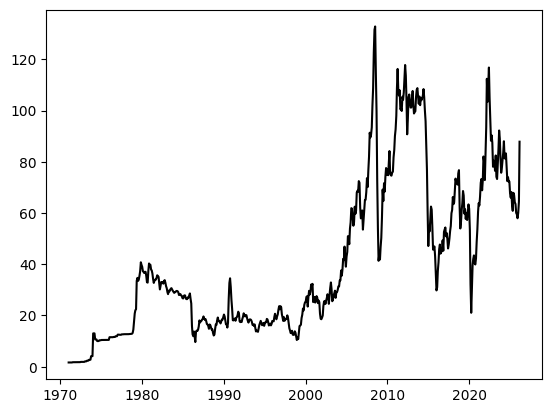

<Figure size 640x480 with 0 Axes>

In [12]:
import matplotlib.pyplot as plt

plt.plot(df['Date'], df['Crude_Oil_Price'], 'black')
plt.show()
plt.clf()

<Axes: >

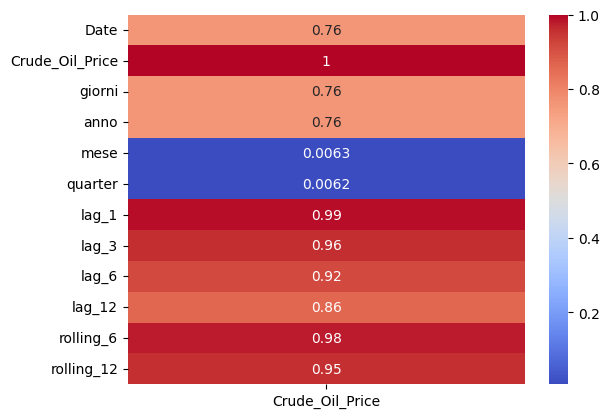

In [13]:
import seaborn as sns

sns.heatmap(df.corr()['Crude_Oil_Price'].to_frame(), annot=True, cmap='coolwarm')

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features = ['giorni', 'anno',
            'lag_6', 'lag_12',
            'rolling_6', 'rolling_12']

x = scaler.fit_transform(df[features])
y = df['Crude_Oil_Price']

split = int(len(df) * 0.8)
x_train, x_test = x[:split], x[split:]
y_train, y_test = y[:split], y[split:]



In [15]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


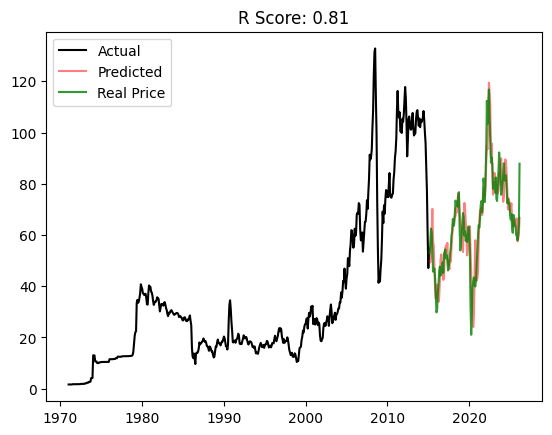

In [16]:
date_test = df['Date'][split:].reset_index(drop=True)
date_train = df['Date'][:split].reset_index(drop=True)

plt.plot(date_train, y_train, 'black', label='Actual')
plt.plot(date_test, lr.predict(x_test), 'red', alpha=0.5,label='Predicted')
plt.plot(date_test, y_test, 'green', alpha=0.8,label='Real Price')
plt.title(f'R Score: {lr.score(x_test, y_test):.2f}')
plt.legend()
plt.show()

In [17]:
import optuna
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800),
        'max_depth':        trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'max_samples':      trial.suggest_float('max_samples', 0.3, 1.0),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }
    
    rf = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    rf.fit(x_train, y_train)
    return r2_score(y_test, rf.predict(x_test))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Migliori parametri:", study.best_params)
print("Miglior R²:", study.best_value)


Best trial: 73. Best value: 0.784987: 100%|██████████| 100/100 [01:47<00:00,  1.07s/it]

Migliori parametri: {'n_estimators': 101, 'max_depth': 3, 'min_samples_leaf': 8, 'min_samples_split': 17, 'max_samples': 0.8289387839239337, 'max_features': None}
Miglior R²: 0.7849870676116113


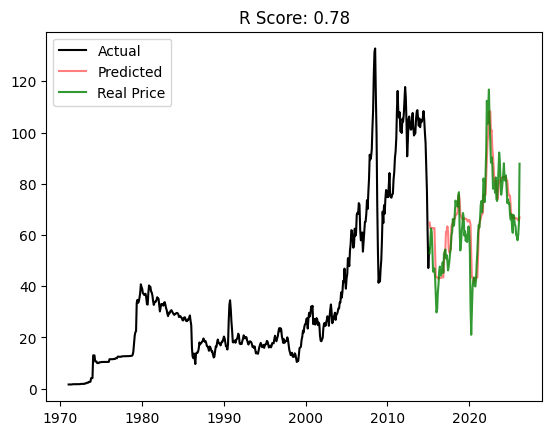

In [18]:
rf = RandomForestRegressor(**study.best_params, random_state=42)
rf.fit(x_train, y_train)

plt.plot(date_train, y_train, 'black', label='Actual')
plt.plot(date_test, rf.predict(x_test), 'red', alpha=0.5,label='Predicted')
plt.plot(date_test, y_test, 'green', alpha=0.8,label='Real Price')
plt.title(f'R Score: {rf.score(x_test, y_test):.2f}')
plt.legend()
plt.show()


# Regressione Lineare vs Random Forest su serie temporali

- Le lag features (lag_1, lag_3...) sono più importanti della scelta del modello
- Con lag_1 la relazione y_t ≈ y_(t-1) è quasi lineare → LR la cattura perfettamente
- Random Forest non extrapola oltre il range del training set → fallisce su test set con valori nuovi
- Regressione Lineare extrapola → funziona meglio quando il test set esce dal range storico
- Su dati complessi e non lineari dentro il range di training → RF/XGBoost torna a vincere


t